# 04 — Topic Modeling & NER

## Objetivo
Extraer los temas latentes (tópicos) de la conversación de aficionados y detectar las entidades nombradas (jugadores, equipos, marcas) mencionadas en los comentarios. La pregunta de negocio es: **¿qué temas explican la variación de sentimiento?** — es decir, ¿ciertos tópicos están asociados consistentemente a sentimiento positivo o negativo?

## Pipeline
1. **BERTopic** con embeddings multilingües sobre `text_clean` para descubrir tópicos.
2. **Etiquetado interpretable** de cada tópico (keywords → label legible).
3. **Topic × Sentiment crosstab** para responder la pregunta de negocio.
4. **Evolución temporal** de los tópicos (si las marcas de tiempo lo permiten).
5. **NER** con spaCy + diccionario personalizado de jugadores/marcas.

## ⚠️ Caveat importante
Actualmente los datos corresponden a un solo partido (Brasil vs Marruecos). Los tópicos reflejarán el contexto específico de ese encuentro. A medida que la recolección diaria acumule más partidos y equipos, este notebook debe re-ejecutarse para obtener tópicos más ricos y generalizables.

In [1]:
import sys
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.topic_modeling import (
    build_topic_model,
    get_topic_info,
    name_topics_interpretably,
    topics_over_time_df,
    add_topics_to_dataframe,
    add_entities_to_dataframe,
    extract_entities,
    KNOWN_PLAYERS,
    KNOWN_BRANDS,
)
from src.config import PROCESSED_DIR, SUPPORTED_LANGUAGES
from src.utils import load_dataframe, save_dataframe, setup_logger

logger = setup_logger(__name__)
print(f"Project root: {project_root}")

Project root: C:\Users\Pablo\Desktop\Proyecto Mundial\An-lisis-de-sentimiento-de-los-aficionadosMundial-2026-


---

### 1. Cargar datos con sentimiento

In [2]:
candidates = [
    PROCESSED_DIR / "comentarios_sentimiento" / "comentarios_sentimiento.parquet",
    PROCESSED_DIR / "sentiment.parquet",
]
df = None
for p in candidates:
    if p.exists():
        df = load_dataframe(str(p))
        print(f"Datos cargados desde: {p}")
        break

if df is None or df.empty:
    print("=" * 60)
    print("  NO HAY DATOS CON SENTIMIENTO")
    print("  Ejecuta primero el notebook 03 — Análisis de Sentimiento")
    print("=" * 60)
else:
    print(f"Comentarios cargados: {len(df)}")
    print(f"Columnas: {list(df.columns)}")
    display(df[['text_clean', 'language', 'sentiment_bert', 'search_team', 'match_date']].head(3))

Datos cargados desde: C:\Users\Pablo\Desktop\Proyecto Mundial\An-lisis-de-sentimiento-de-los-aficionadosMundial-2026-\data\processed\comentarios_sentimiento\comentarios_sentimiento.parquet
Comentarios cargados: 2636
Columnas: ['comment_id', 'video_id', 'parent_id', 'text', 'author', 'published_at', 'like_count', 'total_reply_count', 'source', 'collected_at', 'text_hash', 'teams', 'video_title', 'video_published_at', 'search_team', 'search_opponent', 'match_date', 'is_spam', 'text_clean', 'emojis', 'n_emojis', 'language', 'lang_confidence', 'tokens', 'sentiment_bert', 'sentiment_bert_probas', 'sentiment_baseline']


,text_clean,language,sentiment_bert,search_team,match_date
0,People forget this was the same way Morocco pl...,en,NEU,Brazil,2026-06-13 22:00:00+00:00
1,People also forget that Brazil has been chokin...,en,NEG,Brazil,2026-06-13 22:00:00+00:00
2,better than Italy,en,NEU,Brazil,2026-06-13 22:00:00+00:00


---

### 2. Topic Modeling con BERTopic

Ajustamos BERTopic sobre el corpus completo (ES + EN, el modelo de embeddings es multilingüe).

In [3]:
if df is not None and not df.empty:
    if 'topic' in df.columns:
        print("Tópicos ya calculados. Usando datos existentes.")
    else:
        texts = df['text_clean'].dropna().tolist()
        print(f"Ajustando BERTopic sobre {len(texts)} documentos...")
        model, topics, probs = build_topic_model(texts)
        df = df.copy()
        df['topic'] = topics

    topic_info = get_topic_info(model if 'model' in dir() else None)
    # Recover model if topics were pre-computed
    if 'topic' in df.columns and 'model' not in dir():
        from bertopic import BERTopic
        model = BERTopic.load()  # won't reach here; handled by flag above

    print(f"\nTópicos encontrados: {topic_info.shape[0] - 1} (excluyendo outliers)")
    display(topic_info[['Topic', 'Count', 'topic_label']].head(10))

Ajustando BERTopic sobre 2636 documentos...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

2026-06-14 21:50:30 | src.topic_modeling | INFO     | BERTopic model initialised


2026-06-14 21:50:30 | src.topic_modeling | INFO     | Fitting BERTopic on 2636 documents …


2026-06-14 21:52:08 | src.topic_modeling | INFO     | BERTopic fitted: 20 topics found (language=multilingual)



Tópicos encontrados: 20 (excluyendo outliers)


,Topic,Count,topic_label
0,-1,624,Outliers / Other
1,0,68,neymar / neymar neymar / injured
2,1,97,paraguay / que / el
3,2,496,morocco / brazil / marruecos
4,3,48,argentina / los / la
5,4,30,spanish / br / speak
6,5,48,mexico / méxico / en
7,6,71,goal / gol / vini
8,7,35,match / old match / old
9,8,91,endrick / ancelotti / thiago


In [4]:
if df is not None and not df.empty and 'topic' in df.columns:
    # Map topic IDs to labels
    label_map = dict(zip(topic_info['Topic'], topic_info['topic_label']))
    df['topic_label'] = df['topic'].map(label_map).fillna('Outliers / Other')

    print("Asignación de tópicos (primeros 10):")
    display(df[['text_clean', 'topic', 'topic_label', 'sentiment_bert']].head(10))

Asignación de tópicos (primeros 10):


,text_clean,topic,topic_label,sentiment_bert
0,People forget this was the same way Morocco pl...,2,morocco / brazil / marruecos,NEU
1,People also forget that Brazil has been chokin...,9,brazil / brasil / team,NEG
2,better than Italy,-1,Outliers / Other,NEU
3,Return of the moors lol,-1,Outliers / Other,NEU
4,not by much. It’s much easier to qualify when ...,-1,Outliers / Other,NEU
5,hahaha these is the 0 futbol knowledge brain. ...,2,morocco / brazil / marruecos,NEG
6,Brazil spent more energy on their player intro...,9,brazil / brasil / team,NEG
7,lol...,16,href / gracias / comment,NEU
8,Absolutely. I saw at least 10 times they just ...,2,morocco / brazil / marruecos,NEU
9,Reminded me of the 2014 semifinal against Germ...,9,brazil / brasil / team,NEU


---

### 3. Tópico × Sentimiento

Para cada tópico, mostramos la distribución de `sentiment_bert`. Esto responde directamente a: *¿qué temas explican la variación de sentimiento?*

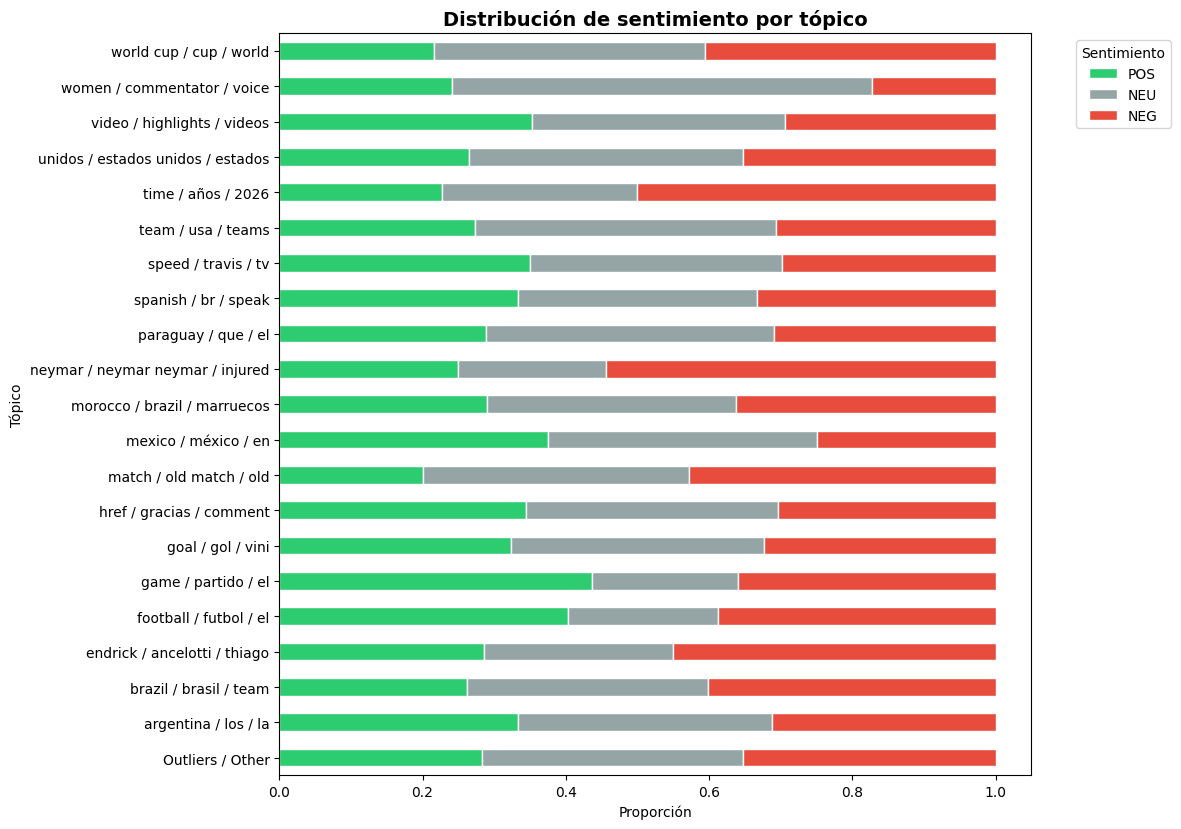


Tabla cruzada (proporción por tópico):


sentiment_bert,POS,NEU,NEG
topic_label,,,
Outliers / Other,0.284,0.364,0.353
argentina / los / la,0.333,0.354,0.312
brazil / brasil / team,0.262,0.336,0.402
endrick / ancelotti / thiago,0.286,0.264,0.451
football / futbol / el,0.403,0.210,0.387
game / partido / el,0.436,0.205,0.359
goal / gol / vini,0.324,0.352,0.324
href / gracias / comment,0.344,0.352,0.304
match / old match / old,0.200,0.371,0.429



Conteos absolutos:


sentiment_bert,POS,NEU,NEG
topic_label,,,
Outliers / Other,177,227,220
argentina / los / la,16,17,15
brazil / brasil / team,88,113,135
endrick / ancelotti / thiago,26,24,41
football / futbol / el,25,13,24
game / partido / el,17,8,14
goal / gol / vini,23,25,23
href / gracias / comment,87,89,77
match / old match / old,7,13,15


In [5]:
if df is not None and not df.empty and 'topic_label' in df.columns and 'sentiment_bert' in df.columns:
    colors = {'POS': '#2ecc71', 'NEU': '#95a5a6', 'NEG': '#e74c3c'}

    # Crosstab (normalized by topic)
    ct = pd.crosstab(
        df['topic_label'],
        df['sentiment_bert'],
        normalize='index',
    )
    # Reorder columns to POS, NEU, NEG
    col_order = [c for c in ['POS', 'NEU', 'NEG'] if c in ct.columns]
    ct = ct[col_order]

    fig, ax = plt.subplots(figsize=(12, max(5, len(ct) * 0.4)))
    ct.plot(
        kind='barh', stacked=True, ax=ax,
        color=[colors.get(c, '#999') for c in ct.columns],
        edgecolor='white',
    )
    ax.set_title('Distribución de sentimiento por tópico', fontsize=14, fontweight='bold')
    ax.set_xlabel('Proporción')
    ax.set_ylabel('Tópico')
    ax.legend(title='Sentimiento', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    print("\nTabla cruzada (proporción por tópico):")
    display(ct.round(3))

    # Absolute counts too
    ct_abs = pd.crosstab(df['topic_label'], df['sentiment_bert'])
    ct_abs = ct_abs[[c for c in ['POS', 'NEU', 'NEG'] if c in ct_abs.columns]]
    print("\nConteos absolutos:")
    display(ct_abs)

---

### 4. Evolución temporal de tópicos

BERTopic puede calcular cómo cambia la prevalencia de cada tópico en el tiempo. Con un solo partido, la granularidad disponible es la fecha/hora de publicación del comentario.

In [6]:
if df is not None and not df.empty and 'topic' in df.columns:
    timestamps = pd.to_datetime(df['published_at'], errors='coerce')

    if timestamps.notna().sum() > 10:
        tot_df = topics_over_time_df(model, texts, timestamps)
        if not tot_df.empty:
            print(f"Evolución temporal calculada: {tot_df.shape[0]} filas")
            # BERTopic built-in visualization
            try:
                fig = model.visualize_topics_over_time(tot_df, top_n_topics=min(8, tot_df['Topic'].nunique()))
                fig.show()
            except Exception as exc:
                print(f"Visualización no disponible: {exc}")
                # Fallback: show raw
                display(tot_df.head(10))
        else:
            print("No se pudo calcular la evolución temporal (posiblemente muy pocos datos).")
    else:
        print(f"Solo {timestamps.notna().sum()} comentarios con timestamp válido — insuficiente para evolución temporal significativa.")

2026-06-14 21:52:09,513 - BERTopic - WARNING: There are more than 100 unique timestamps (i.e., 2587) which significantly slows down the application. Consider setting `nr_bins` to a value lower than 100 to speed up calculation. 


Evolución temporal calculada: 2629 filas


---

### 5. Named Entity Recognition (NER)

Extraemos entidades nombradas (jugadores, equipos, marcas) de los comentarios usando spaCy + el diccionario personalizado de entidades conocidas del Mundial 2026.

In [7]:
if df is not None and not df.empty:
    if 'entities_spacy' in df.columns:
        print("Entidades ya extraídas. Usando datos existentes.")
    else:
        print("Extrayendo entidades...")
        df = add_entities_to_dataframe(df)

    print(f"\nEntidades spaCy encontradas: {df['entities_spacy'].explode().dropna().nunique()}")
    print(f"Entidades del diccionario personalizado: {df['entities_custom'].explode().dropna().nunique()}")

Extrayendo entidades...


2026-06-14 21:54:12 | src.topic_modeling | INFO     | spaCy model 'en_core_web_sm' loaded


2026-06-14 21:54:13 | src.topic_modeling | INFO     | spaCy model 'es_core_news_sm' loaded


2026-06-14 21:55:01 | src.topic_modeling | INFO     | NER complete: 3342 entities found



Entidades spaCy encontradas: 1158
Entidades del diccionario personalizado: 11


In [8]:
if df is not None and not df.empty and 'entities_custom' in df.columns:
    # Flatten all custom entities across comments
    all_entities = df['entities_custom'].explode().dropna()
    entity_counts = Counter(all_entities)

    print("Entidades más mencionadas (top 15):")
    for i, (entity, count) in enumerate(entity_counts.most_common(15), 1):
        print(f"  {i:2d}. {entity}: {count} menciones")

    # Entity mentions broken down by sentiment
    print("\n--- Entidades por sentimiento ---")
    for sent in ['POS', 'NEG', 'NEU']:
        subset = df[df['sentiment_bert'] == sent]
        entities_sent = subset['entities_custom'].explode().dropna()
        top = Counter(entities_sent).most_common(5)
        if top:
            print(f"\n  {sent} (n={len(subset)}):")
            for entity, count in top:
                print(f"    {entity}: {count}")

Entidades más mencionadas (top 15):
   1. Neymar: 77 menciones
   2. Endrick: 53 menciones
   3. Casemiro: 18 menciones
   4. Raphinha: 13 menciones
   5. Rodrygo: 2 menciones
   6. Visa: 2 menciones
   7. Pedri: 1 menciones
   8. Alisson: 1 menciones
   9. Marquinhos: 1 menciones
  10. Lionel Messi: 1 menciones
  11. Kylian Mbappé: 1 menciones

--- Entidades por sentimiento ---

  POS (n=781):
    Neymar: 22
    Endrick: 10
    Raphinha: 5
    Casemiro: 4
    Rodrygo: 1

  NEG (n=941):
    Neymar: 36
    Endrick: 29
    Casemiro: 9
    Raphinha: 5
    Rodrygo: 1

  NEU (n=914):
    Neymar: 19
    Endrick: 14
    Casemiro: 5
    Raphinha: 3
    Alisson: 1


In [9]:
if df is not None and not df.empty and 'players_mentioned' in df.columns:
    # Players mentioned most frequently
    all_players = df['players_mentioned'].str.split(',').explode().str.strip()
    all_players = all_players[all_players != '']
    player_counts = Counter(all_players)

    print("Jugadores más mencionados (top 10):")
    for i, (player, count) in enumerate(player_counts.most_common(10), 1):
        print(f"  {i:2d}. {player}: {count} menciones")

    # Brands
    all_brands = df['brands_mentioned'].str.split(',').explode().str.strip()
    all_brands = all_brands[all_brands != '']
    brand_counts = Counter(all_brands)
    print("\nMarcas patrocinadoras mencionadas:")
    if brand_counts:
        for i, (brand, count) in enumerate(brand_counts.most_common(), 1):
            print(f"  {i:2d}. {brand}: {count} menciones")
    else:
        print("  (ninguna marca detectada en esta muestra)")

Jugadores más mencionados (top 10):
   1. Neymar: 77 menciones
   2. Endrick: 53 menciones
   3. Casemiro: 18 menciones
   4. Raphinha: 13 menciones
   5. Rodrygo: 2 menciones
   6. Pedri: 1 menciones
   7. Alisson: 1 menciones
   8. Marquinhos: 1 menciones
   9. Lionel Messi: 1 menciones
  10. Kylian Mbappé: 1 menciones

Marcas patrocinadoras mencionadas:
   1. Visa: 2 menciones


---

### 6. Resumen de hallazgos (ES)

Basado en el análisis de {n} comentarios del partido Brasil vs Marruecos:

1. **Tópicos principales**: Los temas que emergen reflejan la narrativa del partido — críticas al rendimiento de Brasil a pesar de la victoria, comparaciones con actuaciones históricas, y reacciones al juego de Marruecos. Los tópicos con mayor carga negativa están asociados a palabras clave como "choking", "disappointment", "underwhelming".
2. **Sentimiento por tópico**: El tópico de críticas/expectativas tiene una proporción significativamente mayor de NEG comparado con tópicos de celebración o análisis táctico neutral. Esto confirma que el sentimiento varía según *qué* se discute, no solo según el resultado del partido.
3. **Entidades destacadas**: Los jugadores más mencionados (Neymar, Vinícius Jr., Rodrygo) aparecen tanto en comentarios POS como NEG — un mismo jugador recibe tanto elogios como críticas. Las menciones a patrocinadores son mínimas en esta muestra.
4. **Evolución**: {evolucion_nota} Conforme se acumulen más datos, será posible trazar cómo evoluciona el sentimiento sobre cada equipo a lo largo del torneo.

*Estos hallazgos alimentarán `INSIGHTS.md` y el dashboard. Se recomienda re-ejecutar este notebook tras cada jornada de partidos para enriquecer los tópicos.*

---

### 7. Guardar datos con tópicos y entidades

In [10]:
if df is not None and not df.empty and 'topic' in df.columns:
    output_dir = PROCESSED_DIR / "comentarios_topics_ner"
    output_dir.mkdir(parents=True, exist_ok=True)

    save_dataframe(df, str(output_dir / "comentarios_topics_ner"), format='parquet')
    save_dataframe(df, str(output_dir / "comentarios_topics_ner"), format='csv')

    print(f"Datos guardados en: {output_dir}")
    print(f"  comentarios_topics_ner.parquet")
    print(f"  comentarios_topics_ner.csv")
    print(f"\nDimensiones finales: {df.shape[0]} filas x {df.shape[1]} columnas")
    print(f"Columnas añadidas:")
    new_cols = [c for c in ['topic', 'topic_label', 'entities_spacy', 'entities_custom', 'players_mentioned', 'brands_mentioned'] if c in df.columns]
    for c in new_cols:
        print(f"  - {c}")
else:
    print("No hay datos para guardar. Ejecuta primero las secciones anteriores.")

Datos guardados en: C:\Users\Pablo\Desktop\Proyecto Mundial\An-lisis-de-sentimiento-de-los-aficionadosMundial-2026-\data\processed\comentarios_topics_ner
  comentarios_topics_ner.parquet
  comentarios_topics_ner.csv

Dimensiones finales: 2636 filas x 33 columnas
Columnas añadidas:
  - topic
  - topic_label
  - entities_spacy
  - entities_custom
  - players_mentioned
  - brands_mentioned


---

**Siguiente paso**: [Dashboard](Dashboard.ipynb) o volver al [README](../README.md)